In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/german_credit_data.csv')

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

In [ ]:
df.info

<bound method DataFrame.info of      Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0             0   67    male    2     own             NaN           little   
1             1   22  female    2     own          little         moderate   
2             2   49    male    1     own          little              NaN   
3             3   45    male    2    free          little           little   
4             4   53    male    2    free          little           little   
..          ...  ...     ...  ...     ...             ...              ...   
995         995   31  female    1     own          little              NaN   
996         996   40    male    3     own          little           little   
997         997   38    male    2     own          little              NaN   
998         998   23    male    2    free          little           little   
999         999   27    male    2     own        moderate         moderate   

     Credit amount  Duration              Purpose  
0             1169         6             radio/TV  
1             5951        48             radio/TV  
2             2096        12            education  
3             7882        42  furniture/equipment  
4             4870        24                  car  
..             ...       ...                  ...  
995           1736        12  furniture/equipment  
996           3857        30                  car  
997            804        12             radio/TV  
998           1845        45             radio/TV  
999           4576        45                  car  

[1000 rows x 10 columns]>

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
import zipfile

zip_path = '/content/archive (1).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/german_credit')

print("Extraction completed successfully!")

Extraction completed successfully!


In [ ]:
import os

os.listdir('/content/german_credit')

['german_credit_data.csv']

In [ ]:
df = pd.read_csv('/content/german_credit/german_credit_data.csv')

print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
df['Saving accounts'] = df['Saving accounts'].fillna('Unknown')
df['Checking account'] = df['Checking account'].fillna('Unknown')

print(df.isnull().sum())

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [ ]:
df = df.drop('Unnamed: 0', axis=1)

print(df.columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [ ]:
df['Risk'].value_counts()

,count
Risk,
good,700
bad,300


In [ ]:
X = df.drop('Risk', axis=1)
y = df['Risk']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (1000, 9)
Target (y): (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [ ]:
# Numerical columns
numerical_features = [
    'Age',
    'Job',
    'Credit amount',
    'Duration'
]

# Categorical columns
categorical_features = [
    'Sex',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical features: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
['good' 'good' 'good' 'good' 'good' 'good' 'good' 'good' 'bad' 'good']


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='bad')
recall = recall_score(y_test, y_pred, pos_label='bad')
f1 = f1_score(y_test, y_pred, pos_label='bad')

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.76
Precision: 0.6154
Recall   : 0.5333
F1-Score : 0.5714


Confusion Matrix:
[[120  20]
 [ 28  32]]


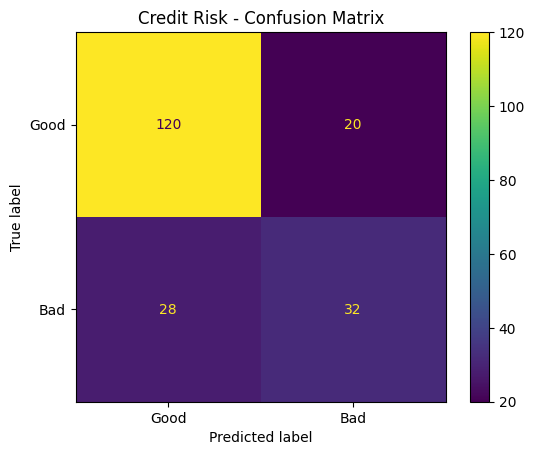

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['good', 'bad'])

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Good', 'Bad']
)

disp.plot()
plt.title("Credit Risk - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probability of the 'bad' class
y_prob = model.predict_proba(X_test)[:, list(model.classes_).index('bad')]

roc_auc = roc_auc_score(
    (y_test == 'bad').astype(int),
    y_prob
)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.7615


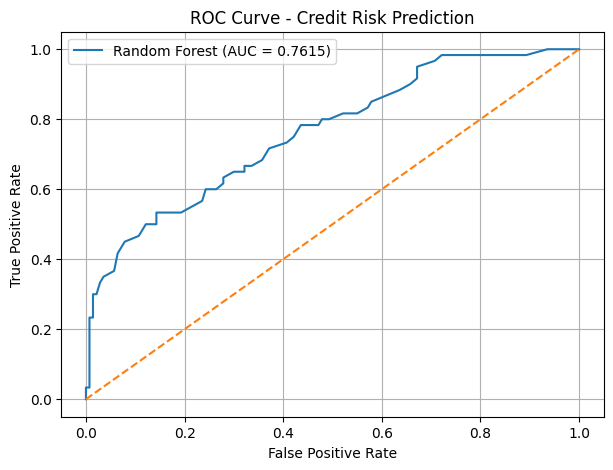

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_test_binary = (y_test == 'bad').astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Prediction')
plt.legend()
plt.grid()
plt.show()

In [ ]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importances = model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
2,num__Credit amount,0.213516
0,num__Age,0.163736
3,num__Duration,0.153829
14,cat__Checking account_Unknown,0.059561
1,num__Job,0.052685
15,cat__Checking account_little,0.041447
19,cat__Purpose_car,0.026347
10,cat__Saving accounts_little,0.025883
23,cat__Purpose_radio/TV,0.023880
16,cat__Checking account_moderate,0.023538


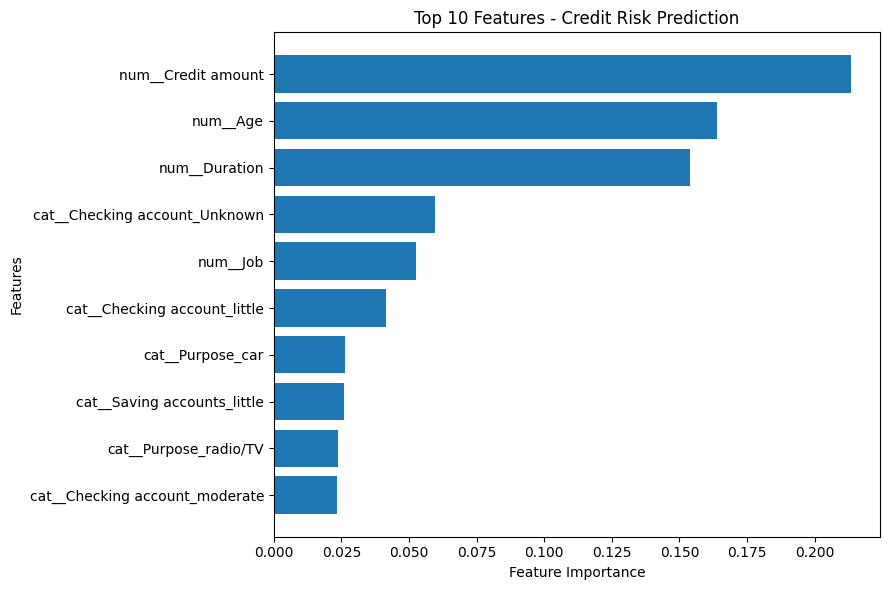

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 10 Features - Credit Risk Prediction')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(model, 'credit_risk_random_forest.pkl')

print("Model saved successfully!")

Model saved successfully!
